# stCOMET Tutorial

This tutorial walks through a complete stCOMET analysis workflow using one DLPFC 10x Visium slice. The goal is to start from raw 10x Visium data, prepare the AnnData object, train stCOMET to learn spatially informed spot embeddings, cluster the spots into spatial domains, evaluate the predicted domains against manual layer annotations, and visualize the results on the tissue image.

The workflow is organized into seven main steps: loading packages, reading data, preprocessing, model training, spatial clustering and refinement, metric calculation, and visualization. Each step produces the objects needed by the following step, so the notebook should be run from top to bottom.

## Loading package

This step imports all Python packages required by the tutorial. `scanpy` is used to read and handle the 10x Visium AnnData object, `torch` is used to select the training device, `pandas` is used to read the metadata file, and `sklearn.metrics` provides the clustering evaluation metrics.

The stCOMET functions are imported from the local package and will be used for preprocessing, model training, spatial clustering, and refinement.

In [ ]:
import sys
from pathlib import Path
from stCOMET import stCOMET, stcomet_spatial_clustering, preprocess_stcomet
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)


## Reading data

This step defines which DLPFC slice will be analyzed and where the downloaded dataset is stored. The `dataset_dir` path should point to the folder containing the 10x Visium files for the selected slice, including `filtered_feature_bc_matrix.h5`, the spatial image files, and `metadata.tsv`.

The data are loaded with `scanpy.read_visium`, which creates an AnnData object containing the gene expression matrix, spatial coordinates, image information, and related metadata. `adata.var_names_make_unique()` ensures that gene names are unique before downstream analysis.

In [ ]:
# Select one DLPFC slice.
slice_id = "151507"
dataset_dir = Path(f"/private_data/summer/liuxy/mydata/1.DLPFC/{slice_id}")  #please replace 'dataset_dir' with the download path
# Load 10x Visium data.
adata = sc.read_visium(
    dataset_dir,
    count_file="filtered_feature_bc_matrix.h5",
    load_images=True,
)
adata.var_names_make_unique()

In [3]:
print(adata)

AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


## Preprocess

This step prepares the AnnData object for stCOMET training. The `preprocess_stcomet` function applies the default preprocessing operations required by the model, such as preparing expression features and graph-related information used in the downstream training process.

After preprocessing, the temporary `feat` and `feat_a` entries are removed from `adata.obsm`. This keeps the AnnData object clean before model training while preserving the information needed by stCOMET.

In [ ]:
# Preprocess data using the default deterministic stCOMET settings.
preprocess_stcomet(adata)
# Remove temporary feature matrices before model training.
adata.obsm.pop("feat", None)
adata.obsm.pop("feat_a", None)

In [5]:
print("Selected genes for encoder:", int(adata.var["highly_variable"].sum()))

Selected genes for encoder: 2530


## Training the model

This step trains the stCOMET model on the preprocessed DLPFC slice. First, the notebook selects a GPU if CUDA is available; otherwise, it uses the CPU. The model is then initialized with the AnnData object, the selected device, the expected number of spatial domains, and the dataset path.

During training, stCOMET learns a low-dimensional embedding for each spot by integrating gene expression and spatial information. The trained embeddings are stored in `adata.obsm["emb"]` and will be used for spatial domain clustering.

In [6]:
# Set the training device and initialize stCOMET.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = stCOMET(
    adata,
    device=device,
    n_clusters=7,
    dataset_path=str(dataset_dir),
)
# Train stCOMET and obtain spot embeddings.
adata = model.train_stcomet()

Using device: cuda:0
Begin to train stCOMET data...


100%|██████████| 450/450 [07:19<00:00,  1.02it/s]



Training completed!


In [7]:

print("AnnData after training:")
print(adata)
print("Embedding shape:", adata.obsm["emb"].shape)

AnnData after training:
AnnData object with n_obs × n_vars = 4226 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'mean', 'std'
    uns: 'spatial', 'gene_module_df', 'gene_module_labels_hvg', 'gene_module_sizes', 'log1p'
    obsm: 'spatial', 'distance_matrix', 'graph_neigh', 'adj', 'feat', 'feat_a', 'emb'
Embedding shape: (4226, 2530)


## Spatial clustering and refinement

This step converts the learned spot embeddings into discrete spatial domains. The `stcomet_spatial_clustering` function clusters the embeddings into the specified number of domains using the selected clustering method.

The refinement option further adjusts predicted labels according to local spatial neighborhoods. This is useful for spatial transcriptomics data because nearby spots are often expected to belong to the same or related tissue regions. The final predicted labels are stored in `adata.obs["domain"]`.

In [8]:
# Perform spatial domain clustering with refinement.
stcomet_spatial_clustering(
    adata,
    n_clusters=7,
    method="mclust",
    radius=50,
    refinement=True,
)

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.
  


<class 'pandas.core.frame.DataFrame'>
fitting ...
  |======================================================================| 100%


## Metric calculation

This step evaluates how well the predicted spatial domains match the manual layer annotations. The ground-truth labels are loaded from `metadata.tsv` and added to `adata.obs["ground_truth"]`.

Only spots with both ground-truth labels and predicted domain labels are used for evaluation. Four metrics are calculated: ARI measures clustering agreement after correcting for chance, NMI measures shared information between the two label sets, completeness measures whether spots from the same ground-truth class are assigned to the same cluster, and homogeneity measures whether each predicted cluster mainly contains spots from one ground-truth class.

In [9]:
# Add ground-truth labels for evaluation.
metadata = pd.read_csv(dataset_dir / "metadata.tsv", sep="\t", index_col=0)
adata.obs["ground_truth"] = metadata.loc[adata.obs_names, "layer_guess"]

In [10]:
# Evaluate clustering metrics.
valid = adata.obs["ground_truth"].notna() & adata.obs["domain"].notna()
y_true = adata.obs.loc[valid, "ground_truth"].astype(str)
y_pred = adata.obs.loc[valid, "domain"].astype(str)

scores = {
    "ARI": adjusted_rand_score(y_true, y_pred),
    "NMI": normalized_mutual_info_score(y_true, y_pred),
    "COM": completeness_score(y_true, y_pred),
    "HOM": homogeneity_score(y_true, y_pred),
}

for name, value in scores.items():
    adata.uns[f"stCOMET_{name}"] = float(value)

print(f"Dataset: {slice_id}")
print(" | ".join(f"{name}: {value:.4f}" for name, value in scores.items()))

Dataset: 151507
ARI: 0.6027 | NMI: 0.7064 | COM: 0.7017 | HOM: 0.7110


## Visualization

This step visualizes the result on the spatial tissue image. The first panel shows the manual ground-truth layer labels, and the second panel shows the spatial domains predicted by stCOMET.

Displaying both panels side by side makes it easier to inspect whether the predicted domains recover the expected cortical layer structure and to visually compare the result with the calculated ARI score.

/tmp/ipykernel_1606962/350175661.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


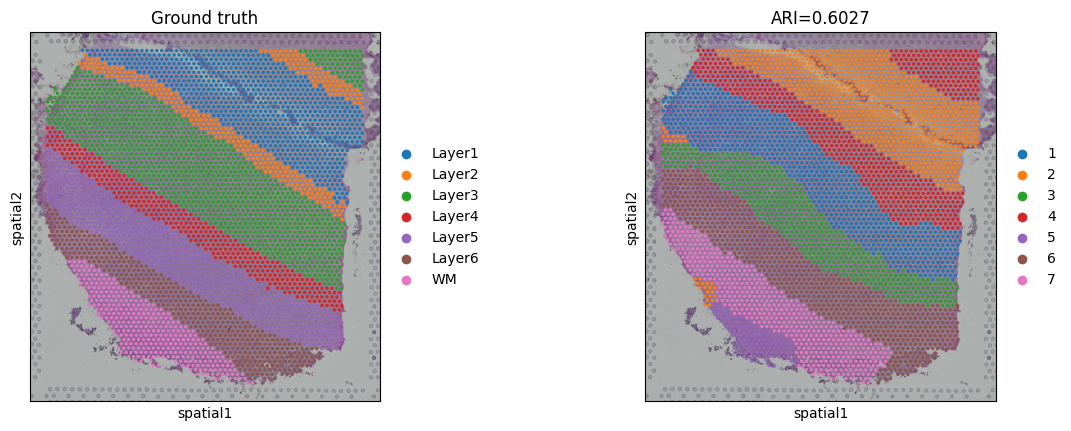

In [11]:
# Plot ground truth and predicted spatial domains.
adata_plot = adata[valid].copy()

sc.pl.spatial(
    adata_plot,
    img_key="hires",
    color=["ground_truth", "domain"],
    title=["Ground truth", f"ARI={scores['ARI']:.4f}"],
    show=True,
)